## RQ1

In [1]:
# ============================================================
# RESET UTILITIES FOR ITERATION 3
# ============================================================

import os
import json
import glob
import shutil
from pathlib import Path
from typing import Union, Optional
import pandas as pd

# Cross-platform path resolution (consistent with Iteration 0, 1 & 2)
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

# Try environment variable first, then search for project root
env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'master_dataset':   BASE_DIR / "Master Dataset 34k",
    'embeddings':       BASE_DIR / "Embeddings" / "_iteration_3",
    'results':          BASE_DIR / "Results" / "_iteration_3"
}

# Normalize all paths and create directories
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

DATA_DIR            = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR         = str(PATHS['results'])
CHECKPOINT_FILE     = str(PATHS['results'] / "checkpoint_iteration_3.json")


# =============================================================================
# Language code mapping (consistent with Iteration 0)
# =============================================================================
LANGUAGE_CODE_MAP = {
    'English': 'EN', 'German': 'DE', 'Swedish': 'SV',
    'Dutch':   'NL', 'Hungarian': 'HU', 'Unknown': 'UN',
}

master_df = pd.read_json(PATHS['master_dataset'] / 'master_df.json')
print(f"Loaded master_df: {len(master_df):,} records, {master_df.shape[1]} columns")

DATASET_FILES = {
    'english_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json'),
    'german_manual':      str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Germany_manual.json'),
    'swedish_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Sweden_manual.json'),
    'dutch_manual':       str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Netherlands_manual.json'),
}


DATASET_FILES = {k: v for k, v in DATASET_FILES.items() if os.path.exists(v)}
print(f"Dataset files available: {list(DATASET_FILES.keys())}")

def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"\n{'='*60}")
            print(f"ITERATION 3 PROGRESS: {len(processed)} combinations processed")
            print(f"{'='*60}")
            print("\nCompleted:")
            for item in processed:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"   {model:40s} → {dataset}")
                else:
                    print(f"   {item}")
    else:
        print(" No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings for iteration 3"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f" Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" All iteration 3 embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print(" Embeddings directory doesn't exist")

def reset_results():
    """Delete all results for iteration 3"""
    if os.path.exists(RESULTS_DIR):
        response = input(f" Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" All iteration 3 results deleted")
        else:
            print(" Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("\n" + "="*60)
    print(" FULL RESET WARNING - ITERATION 3")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart for iteration 3"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN - ITERATION 3")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print(" Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        
        print("\n" + "="*60)
        print(" COMPLETE RERUN READY - ITERATION 3")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print(" Cancelled")

def show_disk_usage():
    """Show disk usage for iteration 3 files"""
    print("\n" + "="*60)
    print(" DISK USAGE - ITERATION 3")
    print("="*60)
    
    # Embeddings size
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        total_size = 0
        file_count = 0
        for root, dirs, files in os.walk(EMBEDDINGS_BASE_DIR):
            for f in files:
                fp = os.path.join(root, f)
                total_size += os.path.getsize(fp)
                file_count += 1
        print(f"Embeddings: {total_size / 1024**3:.2f} GB ({file_count} files)")
    else:
        print("Embeddings: 0 GB (directory doesn't exist)")
    
    # Results size
    if os.path.exists(RESULTS_DIR):
        total_size = sum(os.path.getsize(os.path.join(RESULTS_DIR, f)) 
                        for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f)))
        file_count = len([f for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f))])
        print(f"Results: {total_size / 1024**2:.2f} MB ({file_count} files)")
    else:
        print("Results: 0 MB (directory doesn't exist)")
    
    print("="*60)

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# Show disk usage
# show_disk_usage()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('intfloat/multilingual-e5-large')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print(" RESTART UTILITIES LOADED - ITERATION 3")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  show_disk_usage()            - Check disk usage")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("="*60)
print("\n TIP: To completely restart everything, run: complete_rerun()")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Loaded master_df: 34,576 records, 36 columns
Dataset files available: ['english_manual', 'german_manual', 'swedish_manual', 'dutch_manual']

ITERATION 3 PROGRESS: 1 combinations processed

Completed:
   bert-base-multilingual-uncased           → english_manual

 RESTART UTILITIES LOADED - ITERATION 3
Available functions:
  view_progress()              - See what's completed
  show_disk_usage()            - Check disk usage
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from checkpoint
  remove_specific_dataset(name)- Remove dataset from checkpoint
  reset_embeddings()           - Delete all embeddings
  reset_results()              - Delete all results
  complete_rerun()             - COMPLETE RESTART (everything)

 TIP: To completely restart everything, run: complete_rerun()


In [ ]:
#complete_rerun()

/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



################################################################################
MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE
################################################################################

Models: ['bert-base-multilingual-uncased', 'bert-base-multilingual-cased', 'intfloat/multilingual-e5-base', 'intfloat/multilingual-e5-large', 'intfloat/multilingual-e5-large-instruct']
Batch Size: 12
Max SVM Training Samples: 6000

################################################################################
STARTING PIPELINE EXECUTION
################################################################################

Datasets to process: 4
  english_manual: master_df_English_manual.json
  german_manual: master_df_Germany_manual.json
  swedish_manual: master_df_Sweden_manual.json
  dutch_manual: master_df_Netherlands_manual.json

Total combinations: 20

Already processed: 1 combinations

################################################################################
MODEL: be

/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-multilingual-uncased

 Skipping already processed: english_manual with bert-base-multilingual-uncased

Processing: GERMAN_MANUAL
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-uncased embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 1246/1246 [08:17<00:00,  2.50it/s]



Training set: (11960, 768)
Test set: (2991, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-uncased/german_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 65.05 MB

Checkpoint saved: 2 combinations processed
Progress: 2/20

Processing: SWEDISH_MANUAL
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-uncased embeddings...
Using 

Generating embeddings: 100%|██████████| 1019/1019 [03:20<00:00,  5.09it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-uncased/swedish_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 54.97 MB

Checkpoint saved: 3 combinations processed
Progress: 3/20

Processing: DUTCH_MANUAL
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Ge

Generating embeddings: 100%|██████████| 166/166 [02:06<00:00,  1.32it/s]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-uncased/dutch_manual_bert-base-multilingual-uncased_embeddings.pkl
Size: 6.60 MB

Checkpoint saved: 4 combinations processed
Progress: 4/20

PHASE 2: TRAINING SVM - bert-base-multilingual-uncased

Training SVM: ENGLISH_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 0.68s

Accuracy: 0.7656
F1 Score (weighted): 0.7732
F1 Score (macro): 0.7412

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8846    0.7655    0.8208       661
    Process Safety     0.5822    0.7660    0.6616       282

          accuracy                         0.7656       943
         macro a

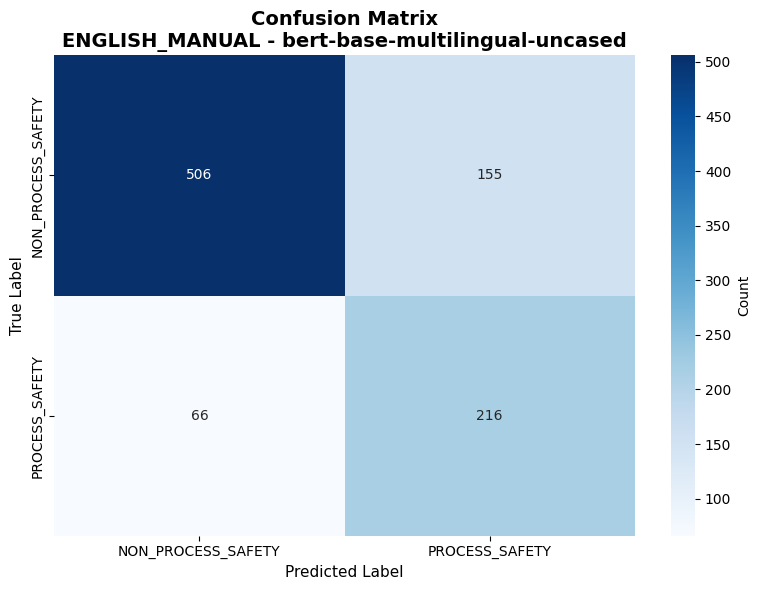


Training SVM: GERMAN_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 1.55s

Accuracy: 0.8024
F1 Score (weighted): 0.8305
F1 Score (macro): 0.6553

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9523    0.8187    0.8805      2659
    Process Safety     0.3163    0.6717    0.4301       332

          accuracy                         0.8024      2991
         macro avg     0.6343    0.7452    0.6553      2991
      weighted avg     0.8817    0.8024    0.8305      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_german_manual_bert-base-multilingual-uncased.png


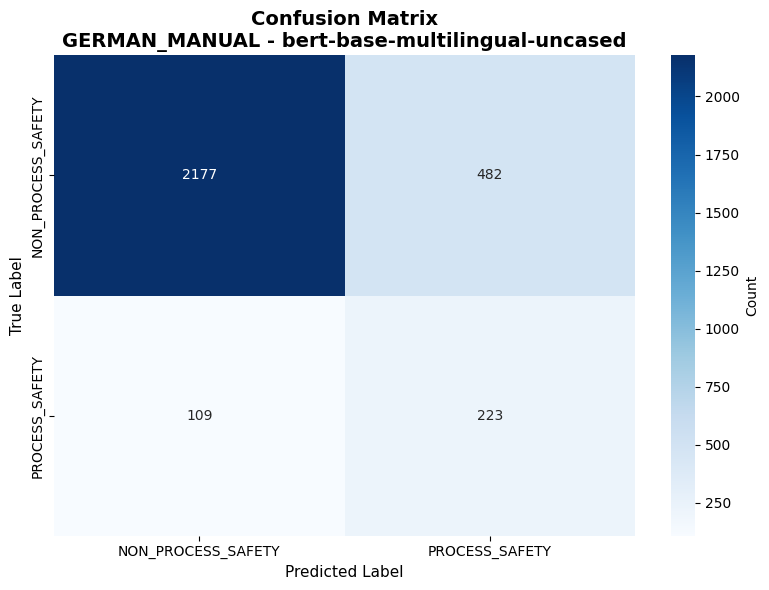


Training SVM: SWEDISH_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 6000
Test samples: 2445

Training LinearSVC...
Training completed in 1.44s

Accuracy: 0.8090
F1 Score (weighted): 0.8489
F1 Score (macro): 0.5583

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9564    0.8341    0.8911      2290
    Process Safety     0.1518    0.4387    0.2255       155

          accuracy                         0.8090      2445
         macro avg     0.5541    0.6364    0.5583      2445
      weighted avg     0.9054    0.8090    0.8489      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_swedish_manual_bert-base-multilingual-uncased.png


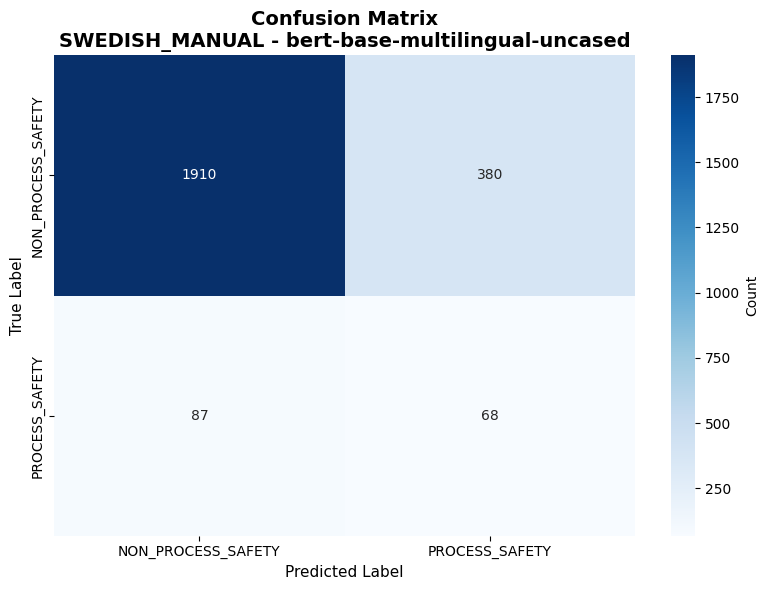


Training SVM: DUTCH_MANUAL | Model: bert-base-multilingual-uncased
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 0.30s

Accuracy: 0.6960
F1 Score (weighted): 0.7070
F1 Score (macro): 0.6672

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8383    0.7036    0.7650       280
    Process Safety     0.4908    0.6780    0.5694       118

          accuracy                         0.6960       398
         macro avg     0.6645    0.6908    0.6672       398
      weighted avg     0.7353    0.6960    0.7070       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_dutch_manual_bert-base-multilingual-uncased.png


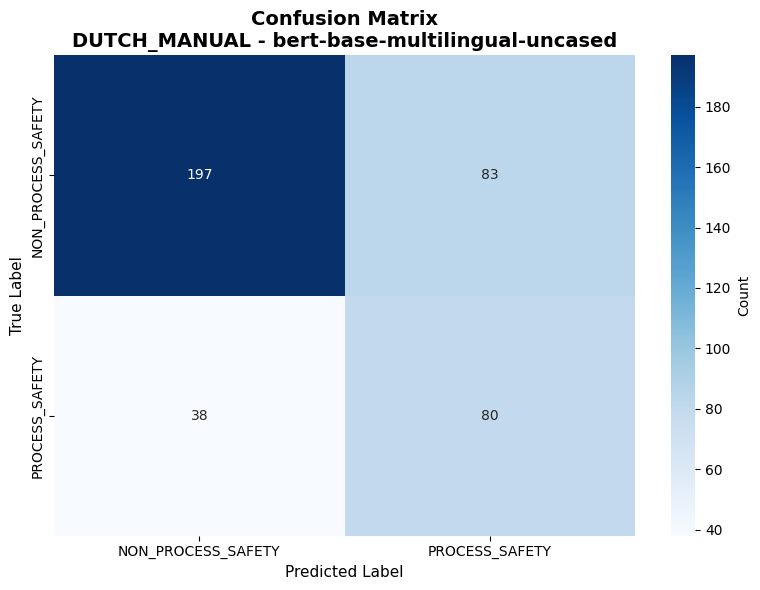


 Completed processing bert-base-multilingual-uncased

################################################################################
MODEL: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
################################################################################

Initializing bert-base-multilingual-cased...


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-multilingual-cased

Processing: ENGLISH_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-cased embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 393/393 [04:10<00:00,  1.57it/s]



Training set: (3770, 768)
Test set: (943, 768)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/english_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 15.36 MB

Checkpoint saved: 5 combinations processed
Progress: 5/20

Processing: GERMAN_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating google-bert/bert-base-multilin

...


Training set: (11960, 768)
Test set: (2991, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/german_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 65.05 MB

Checkpoint saved: 6 combinations processed
Progress: 6/20

Processing: SWEDISH_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-cased embeddings...
Using device: mp

Generating embeddings: 100%|██████████| 1019/1019 [04:39<00:00,  3.64it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/swedish_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 54.97 MB

Checkpoint saved: 7 combinations processed
Progress: 7/20

Processing: DUTCH_MANUAL
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Generating

Generating embeddings: 100%|██████████| 166/166 [02:48<00:00,  1.01s/it]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/bert-base-multilingual-cased/dutch_manual_bert-base-multilingual-cased_embeddings.pkl
Size: 6.60 MB

Checkpoint saved: 8 combinations processed
Progress: 8/20

PHASE 2: TRAINING SVM - bert-base-multilingual-cased

Training SVM: ENGLISH_MANUAL | Model: bert-base-multilingual-cased
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 1.06s

Accuracy: 0.7550
F1 Score (weighted): 0.7619
F1 Score (macro): 0.7262

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8656    0.7700    0.8151       661
    Process Safety     0.5718    0.7199    0.6374       282

          accuracy                         0.7550       943
         macro avg     0

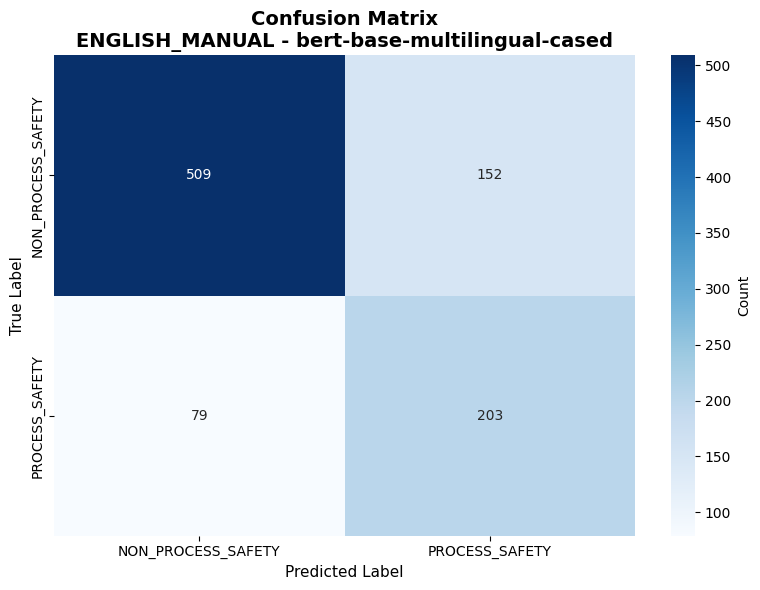


Training SVM: GERMAN_MANUAL | Model: bert-base-multilingual-cased
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 1.95s

Accuracy: 0.8031
F1 Score (weighted): 0.8288
F1 Score (macro): 0.6421

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9427    0.8289    0.8821      2659
    Process Safety     0.3032    0.5964    0.4020       332

          accuracy                         0.8031      2991
         macro avg     0.6230    0.7126    0.6421      2991
      weighted avg     0.8717    0.8031    0.8288      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_german_manual_bert-base-multilingual-cased.png


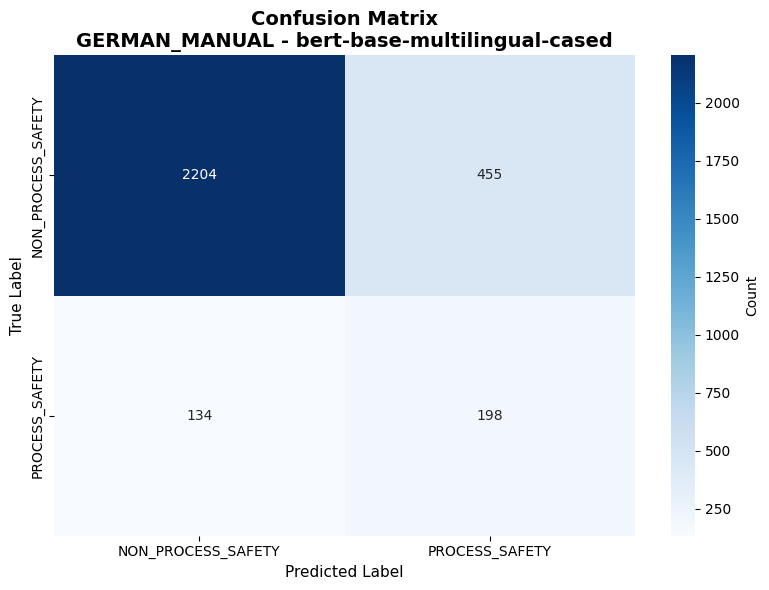


Training SVM: SWEDISH_MANUAL | Model: bert-base-multilingual-cased
Training samples: 6000
Test samples: 2445

Training LinearSVC...
Training completed in 3.72s

Accuracy: 0.8245
F1 Score (weighted): 0.8565
F1 Score (macro): 0.5453

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9493    0.8585    0.9016      2290
    Process Safety     0.1337    0.3226    0.1890       155

          accuracy                         0.8245      2445
         macro avg     0.5415    0.5905    0.5453      2445
      weighted avg     0.8976    0.8245    0.8565      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_swedish_manual_bert-base-multilingual-cased.png


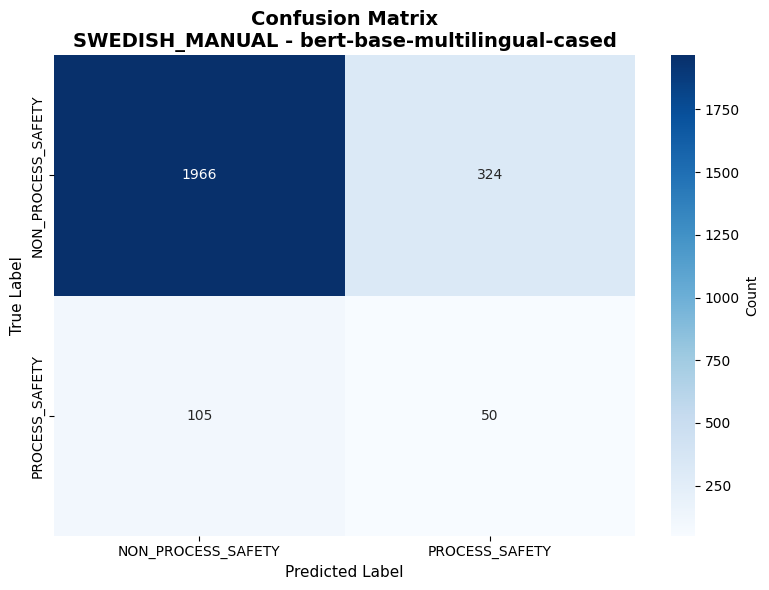


Training SVM: DUTCH_MANUAL | Model: bert-base-multilingual-cased
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 0.39s

Accuracy: 0.6608
F1 Score (weighted): 0.6706
F1 Score (macro): 0.6196

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7912    0.7036    0.7448       280
    Process Safety     0.4430    0.5593    0.4944       118

          accuracy                         0.6608       398
         macro avg     0.6171    0.6314    0.6196       398
      weighted avg     0.6879    0.6608    0.6706       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_dutch_manual_bert-base-multilingual-cased.png


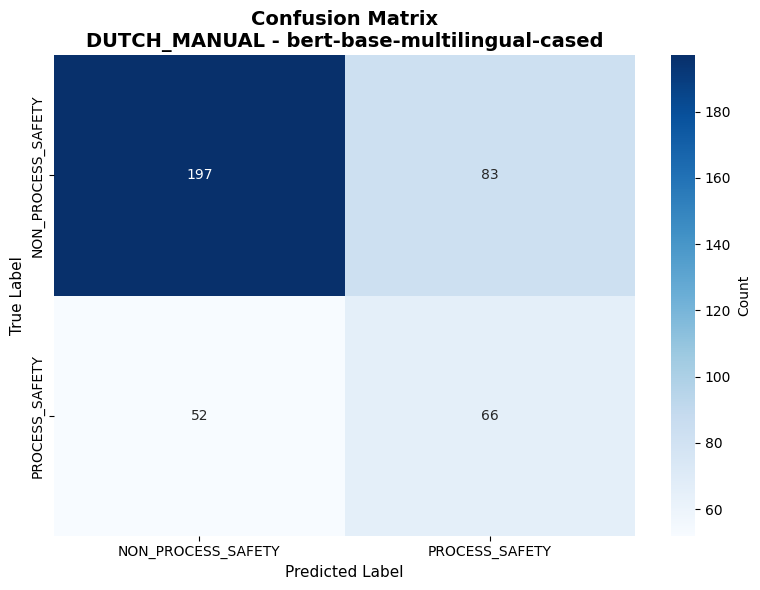


 Completed processing bert-base-multilingual-cased

################################################################################
MODEL: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
################################################################################

Initializing intfloat/multilingual-e5-base...


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-base

Processing: ENGLISH_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 393/393 [05:22<00:00,  1.22it/s]



Training set: (3770, 768)
Test set: (943, 768)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/english_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 15.36 MB

Checkpoint saved: 9 combinations processed
Progress: 9/20

Processing: GERMAN_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddin

...


Training set: (11960, 768)
Test set: (2991, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/german_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 65.05 MB

Checkpoint saved: 10 combinations processed
Progress: 10/20

Processing: SWEDISH_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 1019/1019 [03:23<00:00,  5.00it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/swedish_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 54.97 MB

Checkpoint saved: 11 combinations processed
Progress: 11/20

Processing: DUTCH_MANUAL
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Generating intfl

Generating embeddings: 100%|██████████| 166/166 [02:38<00:00,  1.04it/s]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-base/dutch_manual_intfloat_multilingual-e5-base_embeddings.pkl
Size: 6.60 MB

Checkpoint saved: 12 combinations processed
Progress: 12/20

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-base

Training SVM: ENGLISH_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 1.08s

Accuracy: 0.7741
F1 Score (weighted): 0.7798
F1 Score (macro): 0.7456

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8746    0.7912    0.8308       661
    Process Safety     0.6000    0.7340    0.6603       282

          accuracy                         0.7741       943
         macro avg

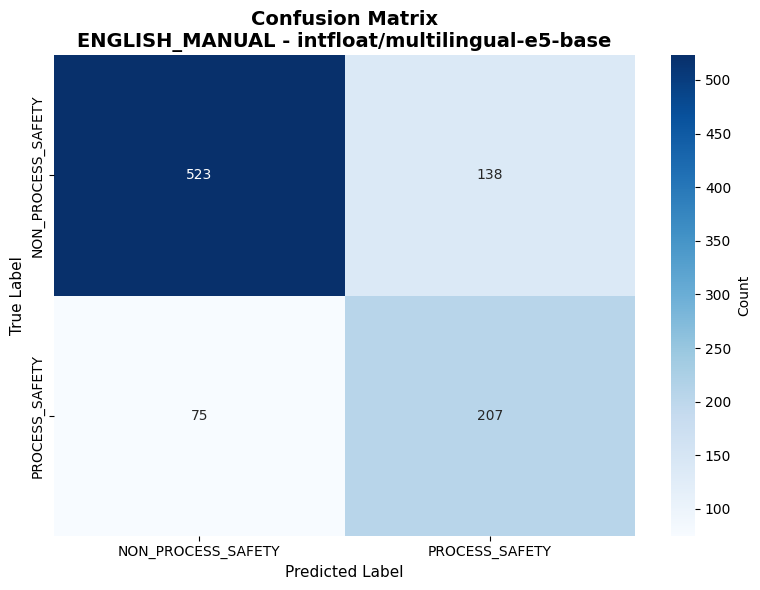


Training SVM: GERMAN_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 2.83s

Accuracy: 0.8101
F1 Score (weighted): 0.8347
F1 Score (macro): 0.6534

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9462    0.8338    0.8864      2659
    Process Safety     0.3179    0.6205    0.4204       332

          accuracy                         0.8101      2991
         macro avg     0.6321    0.7271    0.6534      2991
      weighted avg     0.8765    0.8101    0.8347      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_german_manual_intfloat_multilingual-e5-base.png


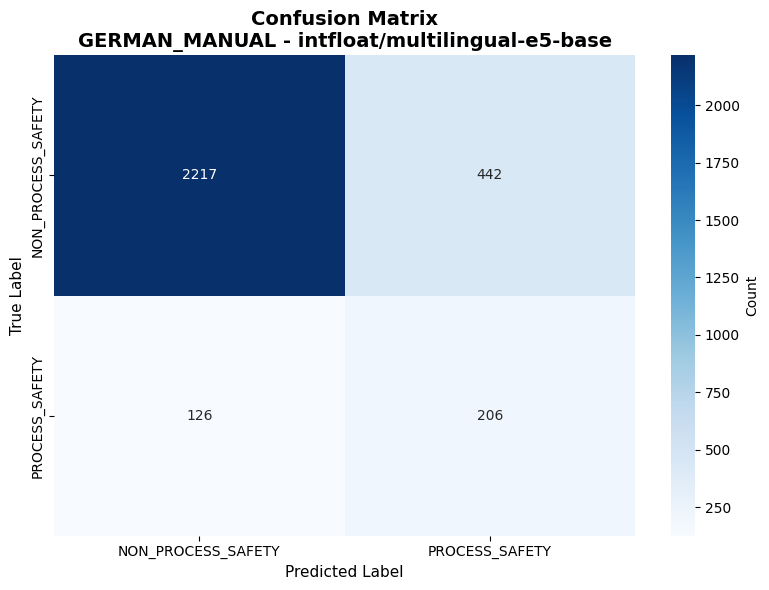


Training SVM: SWEDISH_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 6000
Test samples: 2445

Training LinearSVC...
Training completed in 5.91s

Accuracy: 0.8474
F1 Score (weighted): 0.8713
F1 Score (macro): 0.5668

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9515    0.8821    0.9155      2290
    Process Safety     0.1615    0.3355    0.2180       155

          accuracy                         0.8474      2445
         macro avg     0.5565    0.6088    0.5668      2445
      weighted avg     0.9014    0.8474    0.8713      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_swedish_manual_intfloat_multilingual-e5-base.png


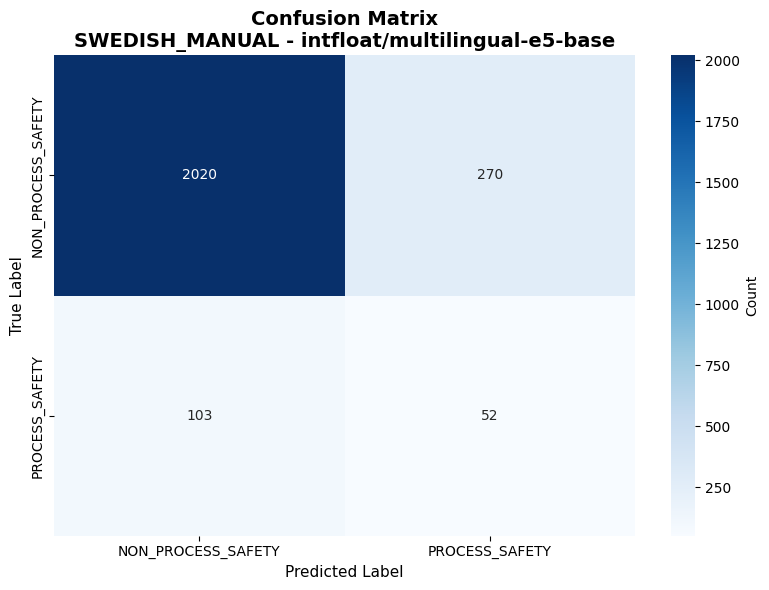


Training SVM: DUTCH_MANUAL | Model: intfloat/multilingual-e5-base
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 0.42s

Accuracy: 0.7085
F1 Score (weighted): 0.7150
F1 Score (macro): 0.6674

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8178    0.7536    0.7844       280
    Process Safety     0.5071    0.6017    0.5504       118

          accuracy                         0.7085       398
         macro avg     0.6625    0.6776    0.6674       398
      weighted avg     0.7257    0.7085    0.7150       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_dutch_manual_intfloat_multilingual-e5-base.png


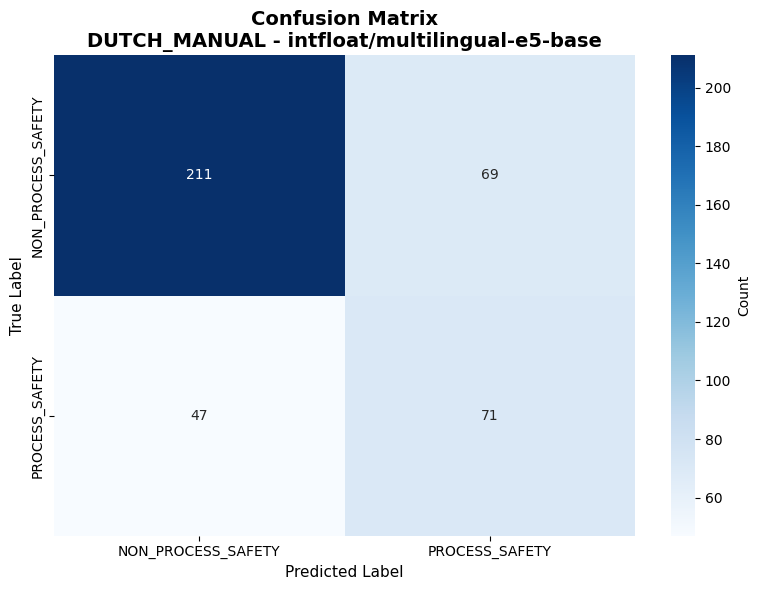


 Completed processing intfloat/multilingual-e5-base

################################################################################
MODEL: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
################################################################################

Initializing intfloat/multilingual-e5-large...


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-large

Processing: ENGLISH_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 393/393 [10:52<00:00,  1.66s/it]



Training set: (3770, 1024)
Test set: (943, 1024)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/english_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 19.96 MB

Checkpoint saved: 13 combinations processed
Progress: 13/20

Processing: GERMAN_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large

...


Training set: (11960, 1024)
Test set: (2991, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/german_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 85.51 MB

Checkpoint saved: 14 combinations processed
Progress: 14/20

Processing: SWEDISH_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 1019/1019 [10:28<00:00,  1.62it/s]



Training set: (9779, 1024)
Test set: (2445, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/swedish_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 72.77 MB

Checkpoint saved: 15 combinations processed
Progress: 15/20

Processing: DUTCH_MANUAL
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Generatin

Generating embeddings: 100%|██████████| 166/166 [06:29<00:00,  2.35s/it]



Training set: (1592, 1024)
Test set: (398, 1024)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large/dutch_manual_intfloat_multilingual-e5-large_embeddings.pkl
Size: 8.54 MB

Checkpoint saved: 16 combinations processed
Progress: 16/20

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-large

Training SVM: ENGLISH_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 1.87s

Accuracy: 0.7646
F1 Score (weighted): 0.7707
F1 Score (macro): 0.7354

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8689    0.7821    0.8232       661
    Process Safety     0.5862    0.7234    0.6476       282

          accuracy                         0.7646       943
         mac

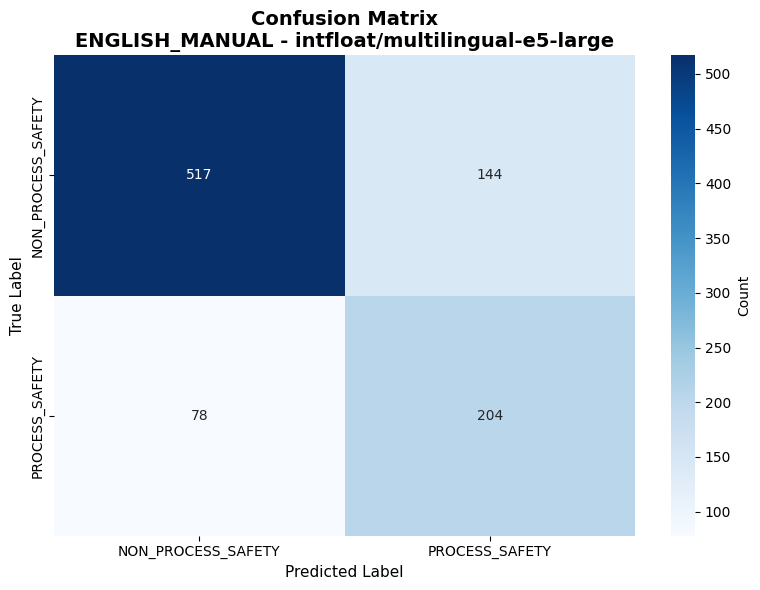


Training SVM: GERMAN_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 17.47s

Accuracy: 0.8342
F1 Score (weighted): 0.8478
F1 Score (macro): 0.6517

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9331    0.8763    0.9038      2659
    Process Safety     0.3340    0.4970    0.3995       332

          accuracy                         0.8342      2991
         macro avg     0.6336    0.6866    0.6517      2991
      weighted avg     0.8666    0.8342    0.8478      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_german_manual_intfloat_multilingual-e5-large.png


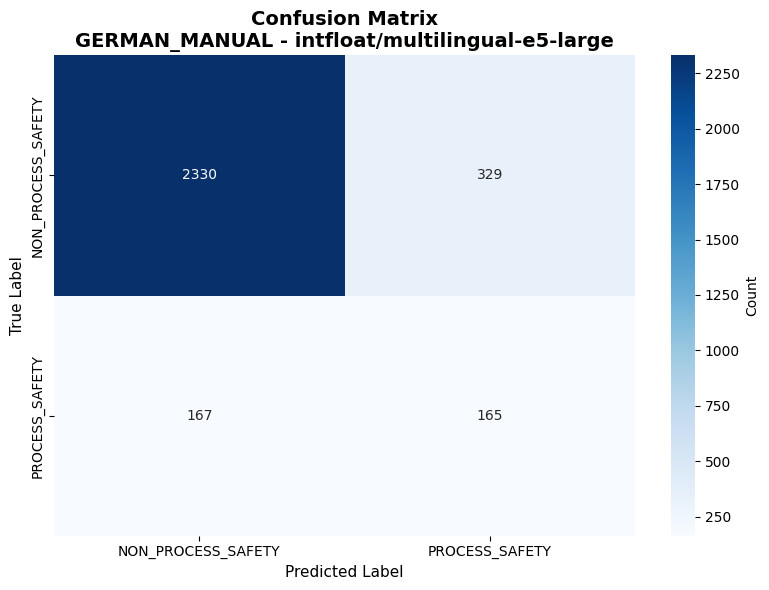


Training SVM: SWEDISH_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 6000
Test samples: 2445

Training LinearSVC...


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training completed in 15.61s

Accuracy: 0.8822
F1 Score (weighted): 0.8895
F1 Score (macro): 0.5660

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9465    0.9266    0.9365      2290
    Process Safety     0.1724    0.2258    0.1955       155

          accuracy                         0.8822      2445
         macro avg     0.5594    0.5762    0.5660      2445
      weighted avg     0.8974    0.8822    0.8895      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_swedish_manual_intfloat_multilingual-e5-large.png


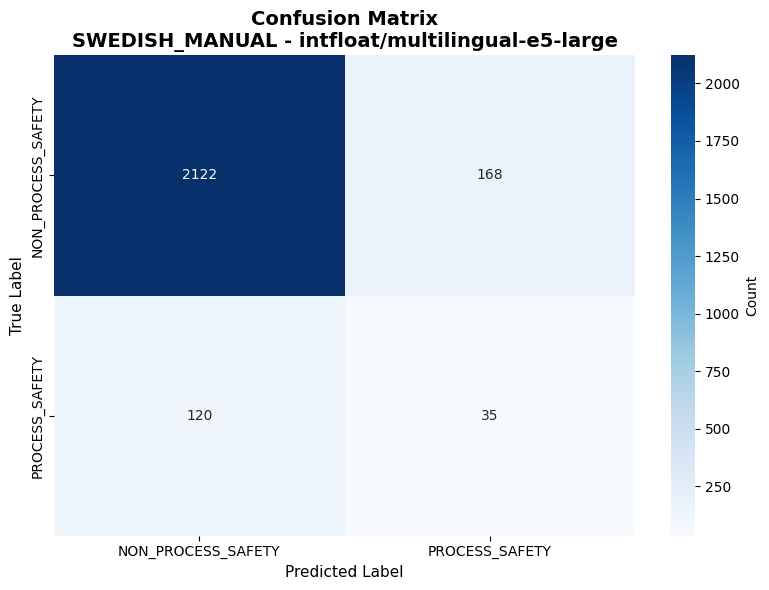


Training SVM: DUTCH_MANUAL | Model: intfloat/multilingual-e5-large
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 1.48s

Accuracy: 0.6859
F1 Score (weighted): 0.6831
F1 Score (macro): 0.6168

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7700    0.7893    0.7795       280
    Process Safety     0.4685    0.4407    0.4541       118

          accuracy                         0.6859       398
         macro avg     0.6193    0.6150    0.6168       398
      weighted avg     0.6806    0.6859    0.6831       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_dutch_manual_intfloat_multilingual-e5-large.png


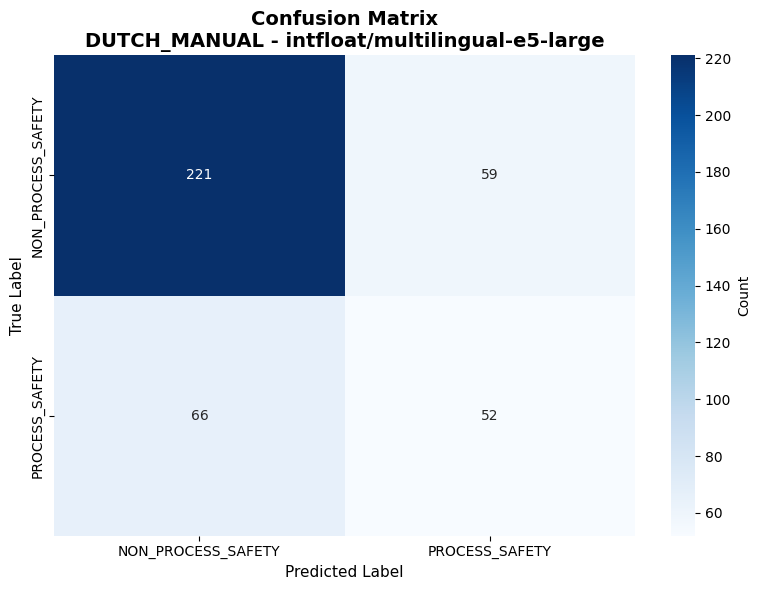


 Completed processing intfloat/multilingual-e5-large

################################################################################
MODEL: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
################################################################################

Initializing intfloat/multilingual-e5-large-instruct...


/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-large-instruct

Processing: ENGLISH_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large-instruct embeddings...
Using device: mps


Generating embeddings: 100%|██████████| 393/393 [10:12<00:00,  1.56s/it]



Training set: (3770, 1024)
Test set: (943, 1024)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/english_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 19.96 MB

Checkpoint saved: 17 combinations processed
Progress: 17/20

Processing: GERMAN_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Gener

...


Training set: (11960, 1024)
Test set: (2991, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/german_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 85.51 MB

Checkpoint saved: 18 combinations processed
Progress: 18/20

Processing: SWEDISH_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large-ins

Generating embeddings: 100%|██████████| 1019/1019 [06:37<00:00,  2.56it/s]



Training set: (9779, 1024)
Test set: (2445, 1024)

Subsampling to 6000 samples for SVM efficiency...
Subsampled training set: (6000, 1024)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/swedish_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 72.77 MB

Checkpoint saved: 19 combinations processed
Progress: 19/20

Processing: DUTCH_MANUAL
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17


Generating embeddings: 100%|██████████| 166/166 [04:49<00:00,  1.75s/it]



Training set: (1592, 1024)
Test set: (398, 1024)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/dutch_manual_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 8.54 MB

Checkpoint saved: 20 combinations processed
Progress: 20/20

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-large-instruct

Training SVM: ENGLISH_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 3770
Test samples: 943

Training LinearSVC...
Training completed in 1.95s

Accuracy: 0.7731
F1 Score (weighted): 0.7775
F1 Score (macro): 0.7407

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8634    0.8033    0.8323       661
    Process Safety     0.6037    0.7021    0.6492       282

          accuracy                  

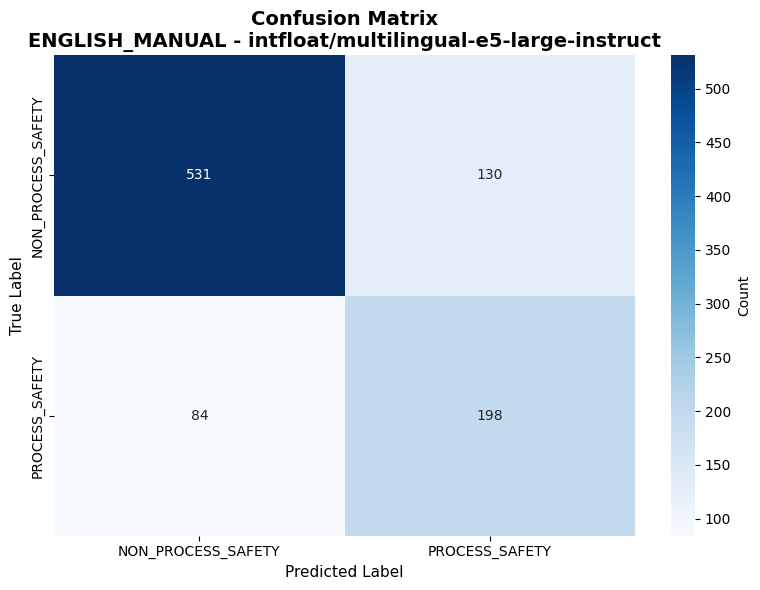


Training SVM: GERMAN_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 6000
Test samples: 2991

Training LinearSVC...
Training completed in 18.18s

Accuracy: 0.8352
F1 Score (weighted): 0.8516
F1 Score (macro): 0.6700

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9424    0.8676    0.9035      2659
    Process Safety     0.3517    0.5753    0.4366       332

          accuracy                         0.8352      2991
         macro avg     0.6471    0.7215    0.6700      2991
      weighted avg     0.8768    0.8352    0.8516      2991


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_german_manual_intfloat_multilingual-e5-large-instruct.png


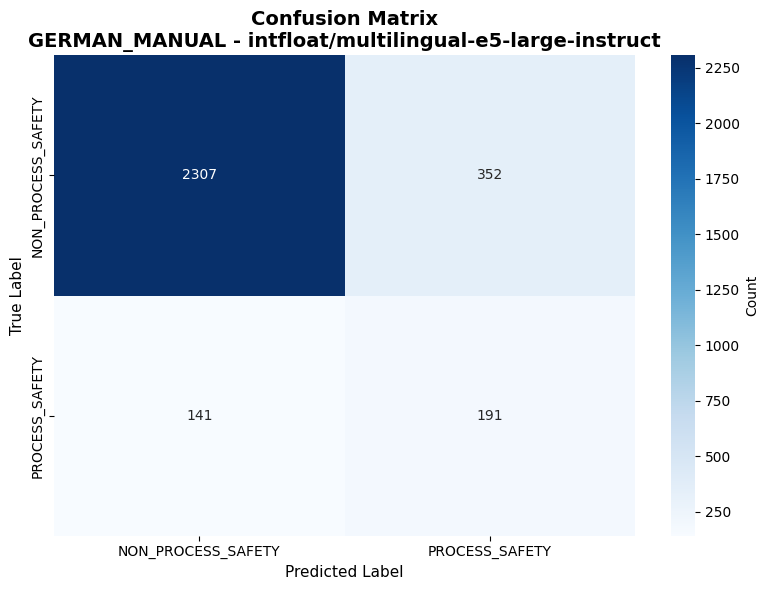


Training SVM: SWEDISH_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 6000
Test samples: 2445

Training LinearSVC...
Training completed in 17.00s

Accuracy: 0.8720
F1 Score (weighted): 0.8843
F1 Score (macro): 0.5670

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9479    0.9135    0.9304      2290
    Process Safety     0.1681    0.2581    0.2036       155

          accuracy                         0.8720      2445
         macro avg     0.5580    0.5858    0.5670      2445
      weighted avg     0.8985    0.8720    0.8843      2445


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_swedish_manual_intfloat_multilingual-e5-large-instruct.png


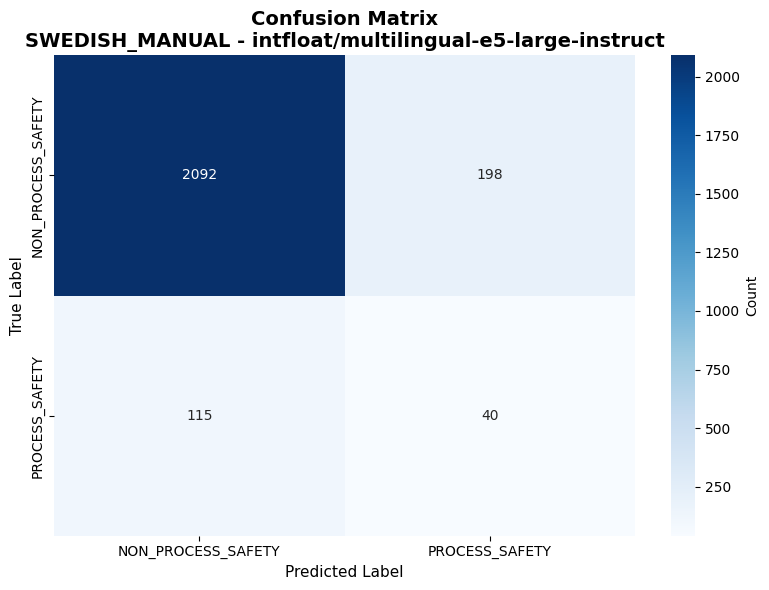


Training SVM: DUTCH_MANUAL | Model: intfloat/multilingual-e5-large-instruct
Training samples: 1592
Test samples: 398

Training LinearSVC...
Training completed in 0.99s

Accuracy: 0.7462
F1 Score (weighted): 0.7477
F1 Score (macro): 0.6995

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8255    0.8107    0.8180       280
    Process Safety     0.5691    0.5932    0.5809       118

          accuracy                         0.7462       398
         macro avg     0.6973    0.7020    0.6995       398
      weighted avg     0.7495    0.7462    0.7477       398


 Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_3/cm_dutch_manual_intfloat_multilingual-e5-large-instruct.png


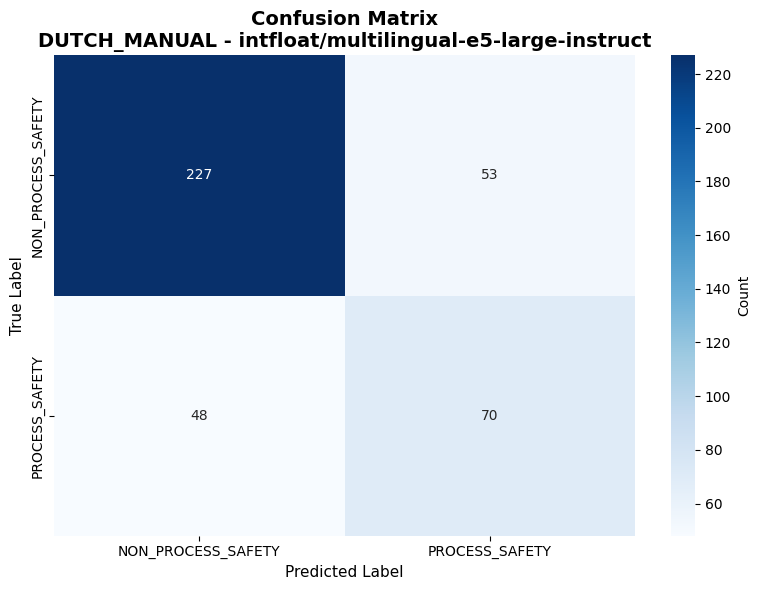


 Completed processing intfloat/multilingual-e5-large-instruct

################################################################################
FINAL COMPREHENSIVE SUMMARY
################################################################################

DETAILED RESULTS TABLE
       dataset                                   model  accuracy  f1_weighted  f1_macro  precision_non_ps  recall_non_ps  f1_non_ps  support_non_ps  precision_ps  recall_ps  f1_ps  support_ps  training_time  subsampled
english_manual          bert-base-multilingual-uncased    0.7656       0.7732    0.7412            0.8846         0.7655     0.8208             661        0.5822     0.7660 0.6616         282           0.68       False
 german_manual          bert-base-multilingual-uncased    0.8024       0.8305    0.6553            0.9523         0.8187     0.8805            2659        0.3163     0.6717 0.4301         332           1.55        True
swedish_manual          bert-base-multilingual-uncased    0.8090 

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time

# ============================================================
# Configuration
# ============================================================

# Use PATHS defined in the setup cell
DATA_DIR = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['results'] / "checkpoint_iteration_3.json")

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Model configurations - Add Llama model
MODELS = {
    'bert-base-multilingual-uncased': 'google-bert/bert-base-multilingual-uncased',
    'bert-base-multilingual-cased': 'google-bert/bert-base-multilingual-cased',
    'intfloat/multilingual-e5-base': 'intfloat/multilingual-e5-base',
    'intfloat/multilingual-e5-large': 'intfloat/multilingual-e5-large',
    'intfloat/multilingual-e5-large-instruct': 'intfloat/multilingual-e5-large-instruct'
}

# Datasets to skip
SKIP_DATASETS = [
    'master_df_Hungary_manual.json',
    'master_df_International_manual.json',
    'master_df_Russia_manual.json',
    'master_df_UAE_manual.json',
    'master_df_Poland_manual.json',
    'master_df_Unknown_manual.json',
]

# Processing settings
BATCH_SIZE = 12
MAX_SAMPLES_SVM = 6000

print("\n" + "#"*80)
print("MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE")
print("#"*80)
print(f"\nModels: {list(MODELS.keys())}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max SVM Training Samples: {MAX_SAMPLES_SVM}")

# ============================================================
# Checkpoint Functions
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)
    print(f"Checkpoint saved: {len(processed_items)} combinations processed")

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            processed = json.load(f)['processed']
            print(f"\n{'='*60}")
            print(f"Progress: {len(processed)} combinations processed")
            print(f"{'='*60}")
            for item in sorted(processed):
                model_key, dataset = item
                print(f"{model_key:30s} → {dataset}")
    else:
        print("\nNo checkpoint found - no progress yet")

def reset_checkpoint():
    """Delete checkpoint to restart"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint cleared")
    else:
        print("No checkpoint found")

# ============================================================
# Embedding Generation Function
# ============================================================

def get_bert_embeddings(texts, tokenizer, model, max_length=512, batch_size=12):
    """Generate embeddings for a list of texts (works for BERT and Llama)"""
    embeddings = []
    device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = model.to(device)
    
    print(f"Using device: {device}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            # Use last hidden state for embeddings (works for both BERT and Llama)
            if hasattr(outputs, 'last_hidden_state'):
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            else:
                # Fallback for models with different output structure
                batch_embeddings = outputs[0][:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        if device == 'mps':
            torch.mps.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)

# ============================================================
# Dataset Processing Function
# ============================================================

def process_dataset(json_file, model_key, model_name, tokenizer, model, dataset_name=None):
    """Process a single JSON dataset and save embeddings"""
    # Always set dataset_name from the key if not provided
    if dataset_name is None:
        dataset_name = os.path.basename(json_file).replace('master_df_', '').replace('.json', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name.upper()}")
    print(f"Model: {model_key} ({model_name})")
    print(f"{'='*80}")
    
    # Load dataset
    df = pd.read_json(json_file)
    if 'LANGUAGE' in df.columns:
        df['LANGUAGE_CODE'] = df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')
    print(f"Dataset shape: {df.shape}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_bert_embeddings(
        df['text_features'].tolist(), 
        tokenizer, 
        model, 
        batch_size=BATCH_SIZE
    )
    y = df['binary_label']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Subsample if training set is too large
    if X_train.shape[0] > MAX_SAMPLES_SVM:
        print(f"\n WARNING: Training set too large ({X_train.shape[0]} samples)")
        print(f"Subsampling to {MAX_SAMPLES_SVM} samples for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train, y_train, 
            n_samples=MAX_SAMPLES_SVM, 
            stratify=y_train, 
            random_state=42
        )
        print(f"Subsampled training set: {X_train_subset.shape}")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    print(f"\nClass distribution in training set:")
    print(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x:.2%}"))
    
    # Create model-specific directory
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_key.replace('/', '_'))
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_subset': X_train_subset,
        'y_train_subset': y_train_subset,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'train_subset_size': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'subsampled': X_train.shape[0] > MAX_SAMPLES_SVM
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory
    del df, X, y, X_train, X_test, y_train, y_test, X_train_subset, y_train_subset, embeddings_data
    gc.collect()
    
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    return pkl_file

# ============================================================
# SVM Training Function
# ============================================================

def train_svm_and_evaluate(embeddings_file):
    """Load embeddings, train SVM, and generate confusion matrix"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    # Use subset for training if available
    X_train = embeddings_data.get('X_train_subset', embeddings_data['X_train'])
    y_train = embeddings_data.get('y_train_subset', embeddings_data['y_train'])
    X_test = embeddings_data['X_test']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"\n{'='*80}")
    print(f"Training SVM: {dataset_name.upper()} | Model: {model_key}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    try:
        print(f"\nTraining LinearSVC...")
        start_time = time.time()
        
        svm_model = LinearSVC(class_weight='balanced', max_iter=1000, dual=False, random_state=42)
        svm_model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f}s")
        
        # Make predictions
        y_pred = svm_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # Get per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        print(f"\nAccuracy: {accuracy:.4f}")
        print(f"F1 Score (weighted): {f1_weighted:.4f}")
        print(f"F1 Score (macro): {f1_macro:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create visualization
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            cbar_kws={'label': 'Count'}
        )
        
        plt.title(f'Confusion Matrix\n{dataset_name.upper()} - {model_key}', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=11)
        plt.xlabel('Predicted Label', fontsize=11)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'cm_{dataset_name}_{model_key.replace("/", "_")}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n Confusion matrix saved to: {plot_path}")
        plt.show()
        
        # Clear memory
        plt.close()
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        
        return {
            'dataset': dataset_name,
            'model': model_key,
            'model_full': metadata['model'],
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'confusion_matrix': cm.tolist(),
            'pkl_file': os.path.basename(embeddings_file),
            'subsampled': metadata.get('subsampled', False)
        }
        
    except Exception as e:
        print(f"\n ERROR training SVM: {str(e)}")
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        raise

# ============================================================
# Main Execution
# ============================================================

print("\n" + "#"*80)
print("STARTING PIPELINE EXECUTION")
print("#"*80)

# Use JSON dataset files defined in Cell 2 (from Iteration 0 outputs)
json_files = list(DATASET_FILES.items())  # [(name, path), ...]

print(f"\nDatasets to process: {len(json_files)}")
for name, path in json_files:
    print(f"  {name}: {os.path.basename(path)}")
print(f"\nTotal combinations: {len(json_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"\nAlready processed: {len(processed_items)} combinations")

# Track results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f"MODEL: {model_key} ({model_name})")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\nInitializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Add padding token if missing (important for Llama)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
            model.config.pad_token_id = model.config.eos_token_id
        
        print(f" Model loaded successfully!")
        
        # Phase 1: Generate embeddings for all datasets
        print(f"\n{'='*80}")
        print(f"PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for dataset_name, json_file in json_files:
            # dataset_name is already the key from DATASET_FILES dict
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\n Skipping already processed: {dataset_name} with {model_key}")
                pkl_file = os.path.join(
                    EMBEDDINGS_BASE_DIR, 
                    model_key.replace('/', '_'),
                    f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl'
                )
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            try:
                # Always pass dataset_name explicitly to avoid local variable errors
                pkl_file = process_dataset(json_file, model_key, model_name, tokenizer, model, dataset_name=dataset_name)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f"Progress: {len(processed_items)}/{len(json_files) * len(MODELS)}")
                
            except Exception as e:
                print(f" ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                continue
        
        # Phase 2: Train SVM for this model's embeddings
        print(f"\n{'='*80}")
        print(f"PHASE 2: TRAINING SVM - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                result = train_svm_and_evaluate(pkl_file)
                all_results.append(result)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f" ERROR training SVM for {dataset_name} with {model_key}: {str(e)}\n")
                all_results.append({
                    'dataset': dataset_name,
                    'model': model_key,
                    'model_full': model_name,
                    'accuracy': None,
                    'f1_weighted': None,
                    'f1_macro': None,
                    'status': f'failed: {str(e)}'
                })
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        
        print(f"\n Completed processing {model_key}")
        
    except Exception as e:
        print(f"\n ERROR loading model {model_key}: {str(e)}")
        print(f"Skipping this model and continuing with next...\n")
        continue

# ============================================================
# Final Summary
# ============================================================

print("\n" + "#"*80)
print("FINAL COMPREHENSIVE SUMMARY")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display results table
    print("="*100)
    print("DETAILED RESULTS TABLE")
    print("="*100)
    
    detailed_cols = [
        'dataset', 'model', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_non_ps', 'recall_non_ps', 'f1_non_ps', 'support_non_ps',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps',
        'training_time', 'subsampled'
    ]
    
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_non_ps', 'recall_non_ps', 'f1_non_ps',
                    'precision_ps', 'recall_ps', 'f1_ps']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save results to CSV
    summary_file = os.path.join(RESULTS_DIR, 'multi_model_svm_results.json')
    results_df.to_json(summary_file, orient='records', indent=2)
    print(f"\n Results saved to: {summary_file}")
    
    # Classification metrics by dataset
    print(f"\n{'='*100}")
    print("CLASSIFICATION METRICS BY MODEL-DATASET COMBINATION")
    print(f"{'='*100}\n")
    
    for idx, row in results_df.iterrows():
        if pd.notna(row.get('accuracy')):
            print(f"Dataset: {row['dataset'].upper():20s} | Model: {row['model']}")
            print("-" * 80)
            print(f"{'':25s} precision    recall  f1-score   support")
            print()
            print(f"{'Non-Process Safety':25s}   {row['precision_non_ps']:.2f}      {row['recall_non_ps']:.2f}      {row['f1_non_ps']:.2f}    {int(row['support_non_ps']):7d}")
            print(f"{'Process Safety':25s}   {row['precision_ps']:.2f}      {row['recall_ps']:.2f}      {row['f1_ps']:.2f}    {int(row['support_ps']):7d}")
            print()
            total_support = int(row['support_non_ps'] + row['support_ps'])
            print(f"{'accuracy':25s}                           {row['accuracy']:.2f}    {total_support:7d}")
            print(f"{'macro avg':25s}   {(row['precision_non_ps'] + row['precision_ps'])/2:.2f}      {(row['recall_non_ps'] + row['recall_ps'])/2:.2f}      {row['f1_macro']:.2f}    {total_support:7d}")
            print(f"{'weighted avg':25s}   {((row['precision_non_ps']*row['support_non_ps'] + row['precision_ps']*row['support_ps'])/total_support):.2f}      {((row['recall_non_ps']*row['support_non_ps'] + row['recall_ps']*row['support_ps'])/total_support):.2f}      {row['f1_weighted']:.2f}    {total_support:7d}")
            print()
    
    # Aggregate statistics
    print(f"\n{'='*80}")
    print("AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total combinations processed: {len(results_df)}")
    print(f"Successful: {results_df['accuracy'].notna().sum()}")
    print(f"Failed: {results_df['accuracy'].isna().sum()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\nOverall Accuracy Statistics:")
        print(f"  Min: {results_df['accuracy'].min():.4f}")
        print(f"  Max: {results_df['accuracy'].max():.4f}")
        print(f"  Mean: {results_df['accuracy'].mean():.4f}")
        print(f"  Std: {results_df['accuracy'].std():.4f}")
        
        print(f"\nF1 Score (Weighted) Statistics:")
        print(f"  Min: {results_df['f1_weighted'].min():.4f}")
        print(f"  Max: {results_df['f1_weighted'].max():.4f}")
        print(f"  Mean: {results_df['f1_weighted'].mean():.4f}")
        print(f"  Std: {results_df['f1_weighted'].std():.4f}")
        
        print(f"\nProcess Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_ps'].mean():.4f}")
        
        print(f"\nNon-Process Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_non_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_non_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_non_ps'].mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\nTraining Time Statistics:")
            print(f"  Min: {results_df['training_time'].min():.2f}s")
            print(f"  Max: {results_df['training_time'].max():.2f}s")
            print(f"  Mean: {results_df['training_time'].mean():.2f}s")
            print(f"  Total: {results_df['training_time'].sum():.2f}s")
        
        # Best performing combination
        best_idx = results_df['accuracy'].idxmax()
        print(f"\n{'='*80}")
        print("BEST PERFORMING COMBINATION (by Accuracy)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_idx, 'model']}")
        print(f"Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"F1 Score (weighted): {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"F1 Score (macro): {results_df.loc[best_idx, 'f1_macro']:.4f}")
        
        # Best for Process Safety class
        best_ps_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print("BEST FOR PROCESS SAFETY CLASS (by F1-Score)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_ps_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_ps_idx, 'model']}")
        print(f"Process Safety F1: {results_df.loc[best_ps_idx, 'f1_ps']:.4f}")
        print(f"Process Safety Precision: {results_df.loc[best_ps_idx, 'precision_ps']:.4f}")
        print(f"Process Safety Recall: {results_df.loc[best_ps_idx, 'recall_ps']:.4f}")
        
        # Average performance by model
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_weighted', 'f1_macro', 
                                                     'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(model_stats.to_string())

else:
    print("No results to display.")

# Clear checkpoint if all completed
total_combinations = len(json_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print(" ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint file cleared.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")
print("\n" + "#"*80)
print(" PIPELINE COMPLETE")
print("#"*80)

# =============================================================================
# Save iteration_3_summary.json (consistent with Iteration 0 format)
# =============================================================================
if all_results:
    import json as _json
    import pandas as _pd

    _results_df = _pd.DataFrame(all_results)
    _RQ1_TARGET = 0.85
    _best_idx = _results_df['macro_f1'].idxmax() if 'macro_f1' in _results_df.columns else 0

    _summary = {
        'iteration': 3,
        'model': '5 multilingual models (google-bert multilingual + intfloat e5 variants) + LinearSVC',
        'best_dataset': str(_results_df.loc[_best_idx, 'dataset']) if len(_results_df) > 0 else '',
        'best_model':   str(_results_df.loc[_best_idx, 'model']) if len(_results_df) > 0 else '',
        'datasets': {},
        'gap_analysis': {}
    }

    for _, row in _results_df.iterrows():
        key = f"{row['dataset']}__{row.get('model', 'unknown')}"
        _summary['datasets'][key] = {
            'results': {
                'accuracy':     round(float(row.get('accuracy', 0)), 4),
                'macro_f1':     round(float(row.get('macro_f1', 0)), 4),
                'precision_ps': round(float(row.get('precision_ps', 0)), 4),
                'recall_ps':    round(float(row.get('recall_ps', 0)), 4),
            }
        }
        _summary['gap_analysis'][key] = {
            'current_macro_f1': round(float(row.get('macro_f1', 0)), 4),
            'rq1_target': _RQ1_TARGET,
            'gap': round(float(_RQ1_TARGET - row.get('macro_f1', 0)), 4)
        }

    _out_path = os.path.join(RESULTS_DIR, 'iteration_3_summary.json')
    with open(_out_path, 'w', encoding='utf-8') as _f:
        _json.dump(_summary, _f, indent=2, ensure_ascii=False)
    print(f"[OK] Saved: {_out_path}")